# Well analysis

## Import Library

In [1]:
# General imports
import re
from pathlib import Path
import os

if os.getcwd().endswith("notebooks"):
    os.chdir("../")
print(f"Current working directory: {os.getcwd()}")

Current working directory: /Volumes/X31/01.Projects/atem


In [2]:
# Image library imports
import ipywidgets as widgets
from IPython.display import display
from matplotlib import pyplot as plt
from rich import print

In [3]:
# Data science imports
import geopandas as gpd
import lasio as ls
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

## Data path setting

In [4]:
# Well Data directory.
well_data_dir: str = Path("data//well")
# Shape file location.
water_well_shp = well_data_dir / "WaterWell_HQ_LAS/Shapefile/WWLAS_CLC_HQ.shp"
print(water_well_shp)
coal_hole_shp = well_data_dir / "CoalHoles_HQ_LAS/Shapefile/CoalHole_CLC_HQ.shp"
print(coal_hole_shp)

data/well/WaterWell_HQ_LAS/Shapefile/WWLAS_CLC_HQ.shp

data/well/CoalHoles_HQ_LAS/Shapefile/CoalHole_CLC_HQ.shp

In [5]:
# .geometry attribute.
ww_gdf = gpd.read_file(water_well_shp).to_crs(epsg=26_912)
ch_gdf = gpd.read_file(coal_hole_shp).to_crs(epsg=26_912)

In [6]:
# DTW
# Wells deeper than 100 m and records with static water levels greater than 50 m below ground surface were excluded.
# Only wells where the static water level occurred within the screened interval (±5 m) were retained
tmp = pd.read_csv(
    "data/Depth_to_Watertable/depth-to-water.csv",
)
tmp = tmp.rename(columns={
    "GicWellId": "name",
    "WellId": "name2",
    "Longitude": "longitude",
    "Latitude": "latitude",
    "WellReportId": "name3",
    "TotalDepthDrilled": "total_depth",
    "DrillingMethod": "drilling_method",
    "DrillingEndDate": "drilling_end_date",
    "ArtesianFlowFlag": "flag",
    "PumpTestId": "pump_id",
    "TestDate": "test_date",
    "StaticWaterLevel": "static_water_level",
    "IntervalFrom": "interval_from",
    "IntervalTo": "interval_to",
})
depth_to_water = gpd.GeoDataFrame(
    tmp,
    geometry=gpd.points_from_xy(tmp["longitude"], tmp["latitude"]),
    crs = "EPSG:4326"
)
depth_to_water = depth_to_water.to_crs(epsg=26_912)
depth_to_water["x"] = depth_to_water.geometry.x
depth_to_water["y"] = depth_to_water.geometry.y

In [7]:
print("Water Well")
print(ww_gdf.columns)
print("Coal Hole")
print(ch_gdf.columns)

Water Well

Index(['LAS_FI_NAM', 'GIC_W_ID', 'LONG_NAD83', 'LAT_NAD83', 'UTM83_Z',
       'E_UTM83', 'N_UTM83', 'E_10TM83', 'N_10TM83', 'EL_DEM15_M', 'DLS_LOC',
       'CURVE_TYPE', 'SHORTNAME', 'PUBLISHER', 'SHORTNAME_', 'geometry'],
      dtype='str')

Coal Hole

Index(['Name', 'Alias2', 'Source_Id', 'Project', 'Litholog', 'E_10TM83',
       'N_10TM83', 'Supplement', 'Spatial_Pr', 'Logger', 'Total_Dept',
       'Depth_Unit', 'Depth_ref', 'El_DR_OUOM', 'El_DR_masl', 'Glgy_done',
       'Litholog_l', 'Hyperlink', 'SP_Res', 'Gam_Bulk', 'SP', 'Conduct',
       'Bulk', 'Gamma', 'Caliper', 'El_AB100', 'Name_1', 'Raster_Typ',
       'geometry'],
      dtype='str')

In [8]:
ww_gdf.head(3)

,LAS_FI_NAM,GIC_W_ID,LONG_NAD83,LAT_NAD83,UTM83_Z,E_UTM83,N_UTM83,E_10TM83,N_10TM83,EL_DEM15_M,DLS_LOC,CURVE_TYPE,SHORTNAME,PUBLISHER,SHORTNAME_,geometry
0,153840-a,153840.0,113.69356,50.17612,12.0,307679.0,5561685.0,593284.0,5559029.0,1062.0,151301428M4,DEPTH BELOW REFERENCE; RESISTIVITY; GAMMA RAY,DEPT; RES; GR,Alberta Geological Survey,3.0,POINT Z (307835.035 5563906.233 1062)
1,153842-a,153842.0,113.69313,50.17582,12.0,307708.0,5561650.0,593316.0,5558996.0,1060.0,151301428M4,DEPTH BELOW REFERENCE; RESISTIVITY; GAMMA RAY,DEPT; RES; GR,Alberta Geological Survey,3.0,POINT Z (307865.242 5563871.539 1060)
2,153926-a,153926.0,112.58949,51.19252,12.0,388931.0,5672434.0,668432.0,5673995.0,945.0,090402619M4,DEPTH BELOW REFERENCE; RESISTIVITY; GAMMA RAY,DEPT; RES; GR,Alberta Geological Survey,3.0,POINT Z (389121.2 5674697.958 945)


In [9]:
# Extract well names.
def pick_name(row, candidates):
    for col in candidates:
        if col in row.index and not pd.isna(row[col]):
            text = str(row[col]).strip()
            if text != "":
                return text
    return None


# Make a container for all well records.
well_records = []

# For Water well.
for _, row in ww_gdf.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    # Extract well name defined with priority: LAS_FI_NAM > Name > SHORTNAME from a given row.
    name = pick_name(row, ["LAS_FI_NAM", "SHORTNAME"])
    if name is None:
        continue
    well_records.append(
        {
            "well_type": "WaterWell",
            "well_name": name,
            "well_id": pick_name(row, ["GIC_W_ID", "GIC_WELL_I"]),
            "x": float(row.geometry.x),
            "y": float(row.geometry.y),
        }
    )

# For Coal hole.
for _, row in ch_gdf.iterrows():
    if row.geometry is None or row.geometry.is_empty:
        continue
    name = pick_name(row, ["Name", "Name_1"])
    if name is None:
        continue
    well_records.append(
        {
            "well_type": "CoalHole",
            "well_name": name,
            "well_id": pick_name(row, ["Source_Id"]),
            "x": float(row.geometry.x),
            "y": float(row.geometry.y),
        }
    )
well_df = pd.DataFrame(well_records)

In [10]:
# Well Type, Well Name, Well ID, X, Y
well_df

,well_type,well_name,well_id,x,y
0,WaterWell,153840-a,153840.0,307835.034573,5.563906e+06
1,WaterWell,153842-a,153842.0,307865.241639,5.563872e+06
2,WaterWell,153926-a,153926.0,389121.199688,5.674698e+06
3,WaterWell,153843-a,153843.0,393054.360097,5.563842e+06
4,WaterWell,153844-a,153844.0,393724.628345,5.559780e+06
...,...,...,...,...,...
72,CoalHole,TH77-76,55.0,411112.686984,5.580320e+06
73,CoalHole,TH78-76,55.0,401396.586685,5.583678e+06
74,CoalHole,TH79-76,55.0,420839.482599,5.577134e+06
75,CoalHole,TH9-83,55.0,414546.097295,5.589883e+06


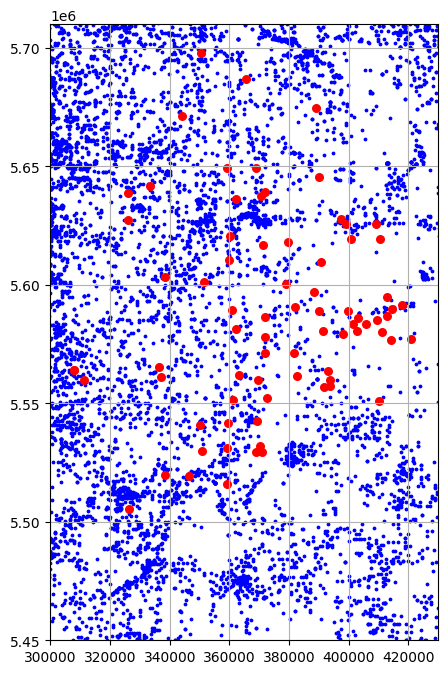

In [11]:
plt.figure(figsize=(5, 8))
plt.scatter(depth_to_water["x"], depth_to_water["y"], s=3, c="blue", label="Depth to Water")
plt.scatter(well_df["x"], well_df["y"], s=30, c="red", label="Wells")
plt.xlim(0.3e6, 0.43e6)
plt.ylim(5.45e6, 5.71e6)
# plt.axis("equal")
plt.grid()

In [12]:
tree = cKDTree(depth_to_water[["x", "y"]])
temp_dis = []

for row in range(well_df.shape[0]):
    test_x = float(well_df.loc[row, "x"])
    test_y = float(well_df.loc[row, "y"])
    distance, valid_index = tree.query([test_x, test_y], k=1)
    temp_dis.append(distance)

Text(0, 0.5, 'Counts')

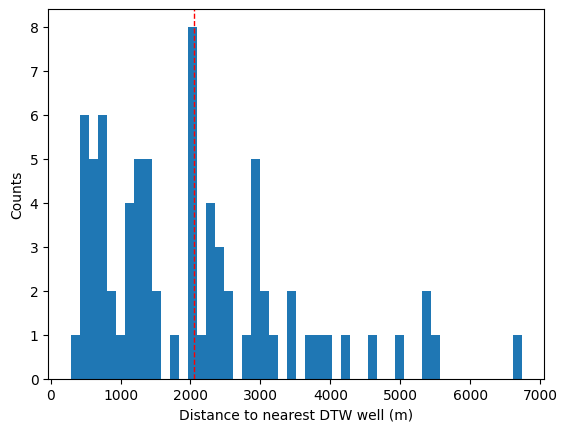

In [13]:
plt.hist(temp_dis, bins = 50)
plt.axvline(np.mean(temp_dis), color="red", linestyle="dashed", linewidth=1, label="Mean")
plt.xlabel("Distance to nearest DTW well (m)")
plt.ylabel("Counts")

In [14]:
cutoff_distance:float = 5_000.0

for row in range(well_df.shape[0]):
    if temp_dis[row] < cutoff_distance:
        values = depth_to_water.loc[valid_index, "static_water_level"]
    else:
        values = np.nan
    well_df.loc[row, "depth_to_water"] = values

In [15]:
well_df

,well_type,well_name,well_id,x,y,depth_to_water
0,WaterWell,153840-a,153840.0,307835.034573,5.563906e+06,6.096
1,WaterWell,153842-a,153842.0,307865.241639,5.563872e+06,6.096
2,WaterWell,153926-a,153926.0,389121.199688,5.674698e+06,6.096
3,WaterWell,153843-a,153843.0,393054.360097,5.563842e+06,6.096
4,WaterWell,153844-a,153844.0,393724.628345,5.559780e+06,6.096
...,...,...,...,...,...,...
72,CoalHole,TH77-76,55.0,411112.686984,5.580320e+06,NaN
73,CoalHole,TH78-76,55.0,401396.586685,5.583678e+06,6.096
74,CoalHole,TH79-76,55.0,420839.482599,5.577134e+06,6.096
75,CoalHole,TH9-83,55.0,414546.097295,5.589883e+06,6.096


## Table

- Well name
- Lithology data
- Colour

### Water well

In [16]:
# Water well Table
water_lith_path = well_data_dir / "WaterWell_HQ_LAS/Tables/WWLAS_CLC_HQ_lithology.DBF"
water_collar_path = well_data_dir / "WaterWell_HQ_LAS/Tables/WWLAS_CLC_HQ_collar.dbf"

## Collar data: XYZ, TD
water_collar_df = gpd.read_file(water_collar_path)
print("WW - Collar")
print(water_collar_df.columns)

## Lithology data: litho type, name, depth top, depth bottom, material1, material2, colour
water_lith_df = gpd.read_file(water_lith_path)
print("WW - Lithology")
print(water_lith_df.columns)

### "GIC_W_ID" & "CIC_W_I" are the same. I guess this is a kind of bore hole name. (Geological information center well ID)

WW - Collar

Index(['LAS_FI_NAM', 'GIC_W_ID', 'LONG_NAD83', 'LAT_NAD83', 'UTM83_Z',
       'E_UTM83', 'N_UTM83', 'E_10TM83', 'N_10TM83', 'EL_DEM15_M', 'DLS_LOC',
       'CURVE_TYPE', 'SHORTNAME', 'PUBLISHER', 'SHORTNAME_'],
      dtype='str')

WW - Lithology

Index(['GIC_WELL_I', 'WELL_REPOR', 'FINALFROM', 'FINALTO', 'WATER_BEAR',
       'COLOUR', 'DESCRIPTIO', 'MATERIAL', 'FINALFROM_', 'FINALTO_M'],
      dtype='str')

### Coal hole well

In [17]:
# Coal hole Table

coal_lith_path = well_data_dir / "CoalHoles_HQ_LAS/Tables/CoalHole_CLC_HQ_Lithology.txt"
coal_collar_path = well_data_dir / "CoalHoles_HQ_LAS/Tables/CoalHole_CLC_HQ_Collar.dbf"

## Collar data: XYZ, TD
coal_collar_df = gpd.read_file(coal_collar_path)
print("Coal - Collar")
print(coal_collar_df.columns)

coal_lith_name = [
    "Name",
    "Source_Id",
    "top_ft",
    "bottom_ft",
    "feet",
    "top_m",
    "bottom_m",
    "tom_m_dup",
    "bottom_m_dup",
    "litho",
    "litho_2",
    "colour",
    "description",
    "dummy",
]

coal_lith_df = pd.read_csv(coal_lith_path, names=coal_lith_name)
print("Coal - Lithology")
print(coal_lith_df.columns)

Coal - Collar

Index(['Name', 'Alias2', 'Source_Id', 'Project', 'Litholog', 'E_10TM83',
       'N_10TM83', 'Supplement', 'Spatial_Pr', 'Logger', 'Total_Dept',
       'Depth_Unit', 'El_DR_OUOM', 'El_DR_masl', 'Glgy_done', 'Litholog_l',
       'Hyperlink', 'SP_Res', 'Gam_Bulk', 'SP', 'Conduct', 'Bulk', 'Gamma',
       'Caliper', 'El_AB100', 'Name_1', 'Raster_Typ'],
      dtype='str')

Coal - Lithology

Index(['Name', 'Source_Id', 'top_ft', 'bottom_ft', 'feet', 'top_m', 'bottom_m',
       'tom_m_dup', 'bottom_m_dup', 'litho', 'litho_2', 'colour',
       'description', 'dummy'],
      dtype='str')

In [18]:
list(coal_lith_df[["Name","top_m","colour"]].head(100).groupby("Name"))

[('TH25-76',
         Name  top_m                                      colour
  84  TH25-76   0.00                                       brown
  85  TH25-76   1.52                                       brown
  86  TH25-76   3.05                                       brown
  87  TH25-76   4.57                                       brown
  88  TH25-76   6.10           green grey, light to medium brown
  89  TH25-76   7.62                            light green grey
  90  TH25-76   9.14                         medium to dark grey
  91  TH25-76  12.19                                 medium grey
  92  TH25-76  15.24                                  light grey
  93  TH25-76  16.76                                 medium grey
  94  TH25-76  18.29                     medium grey, light grey
  95  TH25-76  19.81                        light to medium grey
  96  TH25-76  21.34  light to medium grey, medium to dark brown
  97  TH25-76  22.86                                 medium grey
  98  TH25-7

In [19]:
lithology_columns = ["name", "top_m", "bottom_m", "litho", "colour"]
# water_lith_df, coal_lith_df change the column names to match lithology_columns
water_lith_df = water_lith_df.rename(
    columns={
        "GIC_WELL_I": "name",
        "FINALFROM": "top_m",
        "FINALTO": "bottom_m",
        "MATERIAL": "litho",
        "COLOUR": "colour",
    }
)
coal_lith_df = coal_lith_df.rename(
    columns={
        "Name": "name",
        "top_m": "top_m",
        "bot_m": "bottom_m",
        "litho_1": "litho",
        "colour": "colour",
    }
)

In [20]:
litho_unique: list = np.unique(
    np.asarray(
        list(water_lith_df["litho"].unique()) + list(coal_lith_df["litho"].unique())
        # + list(coal_lith_df["litho_2"].unique())
    )
)

In [21]:
print(litho_unique)

[' gravel, clay' 'Bentonite' 'Boulders' 'Clay' 'Clay & Gravel'
 'Clay & Rocks' 'Clay & Sand' 'Coal' 'Drift' 'Gravel' 'Ironstone'
 'Kelly bushing' 'Old Well' 'Sand' 'Sand & Coal' 'Sand & Gravel'
 'Sandstone' 'Sandstone & Shale Ledges' 'See Comments' 'Shale'
 'Shale & Coal' 'Shale & Sandstone' 'Shale & Sandstone Ledges'
 'Shale & Siltstone' 'Silt' 'Siltstone' 'Siltstone & Coal' 'Till'
 'Till & Clay' 'Till & Gravel' 'Till & Rocks' 'Topsoil' 'Unknown'
 'bentonitic clay' 'bentonitic sand' 'bentonitic sandstone'
 'bentonitic sandstone, shale' 'bentonitic sandy shale' 'bentonitic shale'
 'bentonitic shale, shale' 'bentonitic shale, silty sandstone'
 'bentonitic siltstone' 'bentonitic silty shale'
 'carbonaceous bentonitic shale' 'carbonaceous clayey sandstone'
 'carbonaceous coaly shale' 'carbonaceous sandstone' 'carbonaceous shale'
 'carbonaceous shale, bentonitic shale' 'carbonaceous shale, coal'
 'carbonaceous shale, sandstone' 'carbonaceous shale, shale'
 'carbonaceous shale, siltstone' 'carbonaceous shale, silty shale'
 'carbonaceous siltstone' 'carbonaceous silty shale' 'carboniferous shale'
 'clay' 'clay and sand till' 'clay till' 'clay, shale'
 'clay, shaly sandstone' 'clay, siltstone' 'clayey sandstone' 'coal'
 'coal, carbonaceous shale' 'coal, sandstone' 'coal, shale' 'gravel'
 'gravel, clay' 'gravel, sand' 'no data' 'no recovery' 'sand'
 'sand till, sandy clay' 'sand, clay' 'sand, gravel' 'sand, silt, gravel'
 'sandstone' 'sandstone, carbonaceous shale'
 'sandstone, carbonaceous silty shale' 'sandstone, coal'
 'sandstone, shale' 'sandstone, siltstone' 'sandstone, silty shale'
 'sandy bentonitic shale' 'sandy clay' 'sandy clay till'
 'sandy clay, gravel' 'sandy shale' 'sandy siltstone'
 'sandy siltstone, sandstone' 'sandy siltstone, sandstone, siltstone'
 'sandy till' 'sandy till, gravel' 'sandy, silty clay till'
 'sandy, silty till' 'shale' 'shale, bentonitic sandstone'
 'shale, bentonitic shale' 'shale, carbonaceous shale' 'shale, clay'
 'shale, coal' 'shale, sandstone' 'shale, siltstone'
 'shale, silty sandstone' 'shale, silty shale' 'shaly sandstone'
 'siltstone' 'siltstone, carbonaceous shale' 'siltstone, sandstone'
 'siltstone, shale' 'siltstone, shale, sandstone' 'silty bentonitic clay'
 'silty bentonitic shale' 'silty carbonaceous shale' 'silty clay'
 'silty clay till' 'silty sandstone' 'silty sandstone, shale'
 'silty shale' 'silty shale, sandstone' 'silty shale, shale' 'silty till'
 'silty, bentonitic sandstone' 'silty, bentonitic shale'
 'silty, sandy clay' 'silty, sandy clay till' 'silty, sandy shale' 'soil'
 'till' 'till, carbonaceous siltstone' 'till, gravel' 'till, sand']

## Extract lithology and colour

### Lithology

In [22]:
ELSE_CASE = {
    "no data": "no recovery",
    "no recovery": "no recovery",
    "old well": "no recovery",
    "see comments": "no recovery",
    "unknown": "no recovery",
    "nan": "no recovery",
    "kelly bushing": "no recovery",
}

- regex filter review

In [23]:
PATTERN1 = re.compile(r"(?:\w+\s)*(\w+)(?:,\s)(?:\w+\s)*(\w+)*")
PATTERN2 = re.compile(r"(?:\w+\s)*(\w+)(?:\s&\s)(?:\w+\s)*(\w+)")
PATTERN3 = re.compile(r"^(?:\w+\s)*(\w+)$")

else_case = []
mat1 = []
mat2 = []
mat3 = []
mat4 = []
for text in litho_unique:
    if text.lower() in ELSE_CASE:
        else_case.append(text)
        continue
    matches1 = PATTERN1.search(text.lower())
    matches2 = PATTERN2.search(text.lower())
    matches3 = PATTERN3.search(text.lower())

    if matches1:
        mat1.append((matches1.group(1), matches1.group(2), text))
        print(f"{matches1.group(1)} , {matches1.group(2)} <- {text}")
    if matches2:
        mat2.append((matches2.group(1), matches2.group(2), text))
        print(f"{matches2.group(1)} , {matches2.group(2)} <- {text}")
    if matches3:
        mat3.append((matches3.group(1), text))
        print(f"{matches3.group(1)} <- {text}")

print(f"Length of mat1: {len(mat1)}")
print(f"Length of mat2: {len(mat2)}")
print(f"Length of mat3: {len(mat3)}")
print(f"Length of else_case: {len(else_case)}")
print(
    f"Length of filtered: {len(mat1) + len(mat2) + len(mat3) + len(else_case)}/{len(litho_unique)}"
)


gravel , clay <-  gravel, clay

bentonite <- Bentonite

boulders <- Boulders

clay <- Clay

clay , gravel <- Clay & Gravel

...

Length of mat1: 58

Length of mat2: 14

Length of mat3: 56

Length of else_case: 6

Length of filtered: 134/134

In [24]:
# LITHO_SG = {
#     "boulders": "sg",
#     "drift": "sg",
#     "gravel": "sg",
#     "gravel/clay": "sg",
#     "gravel/sand": "sg",
#     "sand": "sg",
#     "sand/clay": "sg",
#     "sand/coal": "sg",
#     "sand/gravel": "sg",
#     "sand/silt": "sg",
#     "sandstone": "sg",
#     "sandstone/coal": "sg",
#     "sandstone/ledges": "sg",
#     "sandstone/shale": "sg",
#     "sandstone/siltstone": "sg",
#     "silty/sandstone": "sg",
#     "till/gravel": "sg",
#     "till/rocks": "sg",
#     "till/sand": "sg",
#     "coal": "sg",
#     "coal/sandstone": "sg",
#     "coal/shale": "sg",
#     "ironstone": "sg",
# }

# LITHO_CLAY = {
#     "till": "clay",
#     "bentonite": "clay",
#     "clay": "clay",
#     "clay/shale": "clay",
#     "clay/gravel": "clay",
#     "clay/rocks": "clay",
#     "clay/sand": "clay",
#     "clay/sandstone": "clay",
#     "clay/siltstone": "clay",
#     "sandy/till": "clay",
#     "silty/clay": "clay",
#     "silty/till": "clay",
#     "soil": "clay",
#     "till/clay": "clay",
#     "till/siltstone": "clay",
#     "topsoil": "clay",
# }

# LITHO_SHALE = {
#     "shale": "shale",
#     "shale/clay": "shale",
#     "shale/coal": "shale",
#     "shale/ledges": "shale",
#     "shale/sandstone": "shale",
#     "shale/shale": "shale",
#     "shale/siltstone": "shale",
#     "silt": "shale",
#     "siltstone": "shale",
#     "siltstone/coal": "shale",
#     "siltstone/sandstone": "shale",
#     "siltstone/shale": "shale",
#     "silty/shale": "shale",
# }

In [25]:
# 1. SHALE: 순수 고전도성 점토/셰일만 유지
LITHO_SHALE = {
    "shale": "shale",
    "clay": "shale",
    "bentonite": "shale",
    "shale/clay": "shale",
    "shale/shale": "shale",
    "clay/shale": "shale",
    "silty/shale": "shale",
    "silty/clay": "shale",
    "till/clay": "shale",
}

# 2. SG: 사암, 모래, 자갈 및 사질/복합 암상 통합
LITHO_SG = {
    "sand": "sg",
    "sandstone": "sg",
    "gravel": "sg",
    "sand/gravel": "sg",
    "gravel/sand": "sg",
    "sand/silt": "sg",
    "silty/sandstone": "sg",
    "till/sand": "sg",
    "till/gravel": "sg",
    "till/rocks": "sg",
    "sandy/till": "sg",  
    "siltstone/sandstone": "sg",
    "shale/sandstone": "sg",
    "clay/sandstone": "sg",
    "clay/gravel": "sg",
    "clay/sand": "sg",
}

# 3. OTHERS: 석탄, 암석 단애, 불확실/실트계 암상
OTHERS = {
    "coal": "others",
    "coal/sandstone": "others",
    "coal/shale": "others",
    "shale/coal": "others",
    "siltstone/coal": "others",
    "shale/ledges": "others",
    "ironstone": "others",
    "boulders": "others",
    "drift": "others",
    "soil": "others",
    "topsoil": "others",
    "silt": "others",
    "siltstone": "others",
    "clay/rocks": "others",
}

In [26]:
bentonite_search = re.compile(r".*bentonite.*|.*bentonitic.*")

In [27]:
def extract_last_litho(litho_string) -> str:
    text = str(litho_string).lower().strip()
    exception_text = text.replace("/", " ")

    if exception_text in ELSE_CASE:
        return "no recovery"

    match4 = bentonite_search.search(text)
    if match4:
        return "shale"

    match3 = PATTERN3.search(text)
    if match3:
        text_ = match3.group(1)
        if text_ in LITHO_SG:
            return LITHO_SG[text_]
        # if text_ in LITHO_CLAY:
        #     return LITHO_CLAY[text_]
        if text_ in LITHO_SHALE:
            return LITHO_SHALE[text_]
        if text_ in OTHERS:
            return OTHERS[text_]

    match2 = PATTERN2.search(text)
    if match2:
        text_mod1 = match2.group(1) + "/" + match2.group(2)
        if text_mod1 in LITHO_SG:
            return LITHO_SG[text_mod1]
        # if text_mod1 in LITHO_CLAY:
        #     return LITHO_CLAY[text_mod1]
        if text_mod1 in LITHO_SHALE:
            return LITHO_SHALE[text_mod1]
        if text_mod1 in OTHERS:
            return OTHERS[text_mod1]

    match1 = PATTERN1.search(text)
    if match1:
        text_mod1 = match1.group(1) + "/" + match1.group(2)
        if text_mod1 in LITHO_SG:
            return LITHO_SG[text_mod1]
        # if text_mod1 in LITHO_CLAY:
        #     return LITHO_CLAY[text_mod1]
        if text_mod1 in LITHO_SHALE:
            return LITHO_SHALE[text_mod1]
        if text_mod1 in OTHERS:
            return OTHERS[text_mod1]

    # Unknown single-word or unrecognized descriptions are grouped as mixed.
    return "others"

In [28]:
# After convert
test_convert = [extract_last_litho(litho) for litho in litho_unique]
for i in range(len(litho_unique)):
    print(f"{litho_unique[i]} -> {test_convert[i]}")

gravel, clay -> others

Bentonite -> shale

Boulders -> others

Clay -> shale

Clay & Gravel -> sg

...

soil -> others

till -> others

till, carbonaceous siltstone -> others

till, gravel -> sg

till, sand -> sg

### Colour

In [29]:
def allocate_color(litho_string) -> str:
    """
    Extract the last lithology term from a lithology string.
    """
    litho_string = litho_string.lower()
    if litho_string == "sg":
        out = "yellow"
    elif litho_string == "clay":
        out = "blue"
    elif litho_string == "shale":
        out = "green"
    elif litho_string == "others":
        out = "cyan"
    else:
        out = "none"
    return out


print(allocate_color("clay"))

blue

- Apply modified lithology and colour

In [30]:
water_lith_df["litho"] = water_lith_df["litho"].apply(extract_last_litho)
coal_lith_df["litho"] = coal_lith_df["litho"].apply(extract_last_litho)
water_lith_df["colour"] = water_lith_df["litho"].apply(allocate_color)
coal_lith_df["colour"] = coal_lith_df["litho"].apply(allocate_color)

In [31]:
print(np.sum(water_lith_df["litho"] == "sg"))
# print(np.sum(coal_lith_df["litho"] == "clay"))
print(np.sum(coal_lith_df["litho"] == "shale"))
print(np.sum(coal_lith_df["litho"] == "others"))

135

1824

279

## LAS file

In [32]:
water_items = []
for path in water_lith_df["name"].unique():
    las_file = well_data_dir / f"WaterWell_HQ_LAS/LAS_Files/{int(path)}-a.las"
    if not las_file.exists():
        print(f"LAS file not found: {las_file}")
        continue
    las = ls.read(las_file)
    col_name = las.df().columns
    water_items.extend(list(col_name))
water_items = list(set(water_items))

In [33]:
coal_items = []
for path in coal_lith_df["name"].unique():
    las_file = well_data_dir / f"CoalHoles_HQ_LAS/LAS_Files/Litholog_{(path)}.las"
    if las_file.exists():
        las = ls.read(las_file)
        col_name = las.df().columns
        coal_items.extend(list(col_name))
    else:
        las_file_A = (
            well_data_dir / f"CoalHoles_HQ_LAS/LAS_Files/Litholog_{(path)}_A.las"
        )
        las_file_B = (
            well_data_dir / f"CoalHoles_HQ_LAS/LAS_Files/Litholog_{(path)}_B.las"
        )
        las_A = ls.read(las_file_A)
        las_B = ls.read(las_file_B)
        col_name = las_A.df().join(las_B.df(), how="outer").columns
        coal_items.extend(list(col_name))
coal_items = list(set(coal_items))

Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}
Conflicting index units found: {'M', 'FT'}


In [34]:
print(water_items)
print(coal_items)

['RES3', 'RES', 'RES2', 'RES1', 'GR']

['CILD', 'IND', 'SFR', 'CAL', 'BDEN', 'DC', 'RES', 'SP', 'GR']

In [35]:
print(las_B.curves["IND"].unit)  # Induction log, unit: ohmm
print(las_B.curves["SP"].unit)  # Spontaneous potential, unit: mV
print(
    las_B.curves["SFR"].unit
)  # Shallow focus resistivity, unit: ohm-m (Not proper to compare with ATEM results)
print(
    las_B.curves["CILD"].unit
)  # MMHO (S/M) > The value is fixed to some constant, not proper to compare with ATEM results
print(las_A.curves["DC"].unit)  # G/C3: (g/cm^3) Density correction
print(las_A.curves["BDEN"].unit)  # G/C3: (g/cm^3)  or RHOB
print(las_A.curves["CAL"].unit)  # Inch

OHMM

MV

OHMM

MMHO

G/C3

G/C3

IN

In [36]:
# list_res = ["RES", "RES1", "RES2", "RES3", "CILD", "IND"]
list_res = ["RES", "RES1", "RES2", "RES3", "CILD"]
# list_res = ["RES", "RES1", "RES2", "RES3"]

In [37]:
def load_well_las(well_name: str, well_type: str):
    if well_type == "WaterWell":
        las_path = well_data_dir / f"WaterWell_HQ_LAS/LAS_Files/{well_name}.las"
        las_path = [las_path]
    else:
        tmp = well_data_dir / "CoalHoles_HQ_LAS/LAS_Files/"
        las_path = [
            tmp / f"Litholog_{well_name}.las",
            tmp / f"Litholog_{well_name}_A.las",
            tmp / f"Litholog_{well_name}_B.las",
        ]

    existing_paths = [path for path in las_path if path.exists()]
    if not existing_paths:
        return None, None, None, None, None, None  # DEPT, RES, GR, SP, CAL, Bit size

    df = []
    for path in existing_paths:
        las = ls.read(path)
        df_las = las.df()
        depth = np.asarray(df_las.index.values, dtype=float)
        units = las.curves[0].unit  # Depth unit
        has_units = units is not None
        has_ft = units.lower() in ["ft", "feet"]
        if has_units * has_ft:
            depth = depth * 0.3048  # Convert feet to meters
        df_las.index = depth
        df.append(df_las)

    combined_las = pd.concat(df).sort_index()
    depth = np.asarray(combined_las.index.values, dtype=float)

    res = None
    for col in list_res:
        if col in combined_las.columns:
            values = pd.to_numeric(combined_las[col], errors="coerce").to_numpy(
                dtype=float
            )
            if col == "CILD":
                values = 1000.0 / (values + 1e-6)
            res = values
            break

    # if res is None:
    #     return None, None

    gr = None
    for col in ["GR"]:
        if col in combined_las.columns:
            gr = pd.to_numeric(combined_las[col], errors="coerce").to_numpy(dtype=float)
            break

    sp = None
    for col in ["SP"]:
        if col in combined_las.columns:
            sp = pd.to_numeric(combined_las[col], errors="coerce").to_numpy(dtype=float)
            break
    cal = None
    for col in ["CAL"]:
        if col in combined_las.columns:
            cal = pd.to_numeric(combined_las[col], errors="coerce").to_numpy(
                dtype=float
            )
            break

    bit_size = None
    for col in ["BS"]:
        if col in las.params:
            bit_size = las.params[col].value
            break

    # mask = (
    #     np.isfinite(depth) & np.isfinite(res) & (depth >= 0) & (res > 0) & (res < 1e3)
    # )
    if res is None:
        if gr is None:
            if sp is None:
                if cal is None:
                    return None, None, None, None, None, bit_size
                else:
                    return depth, None, None, None, cal, bit_size
            else:
                if cal is None:
                    return depth, None, None, sp, None, bit_size
                else:
                    return depth, None, None, sp, cal, bit_size
        else:
            if sp is None:
                if cal is None:
                    return depth, None, gr, None, None, bit_size
                else:
                    return depth, None, gr, None, cal, bit_size
            else:
                if cal is None:
                    return depth, None, gr, sp, None, bit_size
                else:
                    return depth, None, gr, sp, cal, bit_size
    else:
        if gr is None:
            if sp is None:
                if cal is None:
                    return depth, res, None, None, None, bit_size
                else:
                    return depth, res, None, None, cal, bit_size
            else:
                if cal is None:
                    return depth, res, None, sp, None, bit_size
                else:
                    return depth, res, None, sp, cal, bit_size
        else:
            if sp is None:
                if cal is None:
                    return depth, res, gr, None, None, bit_size
                else:
                    return depth, res, gr, None, cal, bit_size
            else:
                if cal is None:
                    return depth, res, gr, sp, None, bit_size
                else:
                    return depth, res, gr, sp, cal, bit_size

## AEM data

In [38]:
# ATEM inversion data
atem_data_dir: str = Path(
    "outputs/merged_inversion_results/merged_iteration_14_resistivity_wide-1.csv"
)

atem_df = pd.read_csv(atem_data_dir)

for col in ["x_wgs84", "y_wgs84", "distance", "dtm", "bheight"]:
    if col in atem_df.columns:
        atem_df[col] = pd.to_numeric(
            atem_df[col], errors="coerce"
        )  # "coerce" set invalid values to NaN.
if "Line" in atem_df.columns:
    atem_df["Line"] = atem_df["Line"].astype(str)

rho_cols = [c for c in atem_df.columns if c.startswith("rho_") and c.endswith("m")]
if len(rho_cols) == 0:
    raise ValueError(
        "No resistivity columns found in CSV (expected rho_XX.XXm columns)"
    )


# Get depth values from column names with "regex".
def parse_depth_from_col(col_name):
    # (...) is a capturing group (create a groups).
    # [0-9]+ matches any digit from 0 to 9, one or more.
    # (?:...) is a non-capturing group (don't create a group).
    # \.[0-9]+ matches with . followed by one or more digits.
    # ()? makes the previous group optional (0 or 1 times).
    match = re.match(r"rho_([0-9]+(?:\.[0-9]+)?)m", col_name)
    return float(match.group(1)) if match else np.nan


depth_values = np.array([parse_depth_from_col(c) for c in rho_cols], dtype=float)
resis_values = atem_df[rho_cols].to_numpy(dtype=float)

In [39]:
xy = atem_df[["x_wgs84", "y_wgs84"]].to_numpy(dtype=float)
xy_valid_maks = np.isfinite(xy).all(axis=1)
valid_atem_df = atem_df.loc[xy_valid_maks].reset_index(drop=True)
xy_valid = valid_atem_df[["x_wgs84", "y_wgs84"]].to_numpy(dtype=float)

# Build a KDTree model
model_tree = cKDTree(xy_valid)

In [40]:
# Interpolation parameters.
k_nearst_points: int = 100  # Select the number of nearest points for interpolation.
max_distance: float = 1000.0  # Maximum distance for interpolation (in meters).
idw_power: float = 0.0  # Inverse Distance Weighting.
map_dx = 100.0  # Grid spacing (X)
map_dy = 100.0  # Grid spacing (Y)
x_pad = 1000.0  # Padding for X axis (in meters)
y_pad = 1000.0  # Padding for Y axis (in meters)

# Create a grid for interpolation.
xmin = np.nanmin(xy_valid[:, 0]) - x_pad  # Minimum X value minus padding
ymin = np.nanmin(xy_valid[:, 1]) - y_pad  # Minimum Y value minus padding
xmax = np.nanmax(xy_valid[:, 0]) + x_pad  # Maximum X value plus padding
ymax = np.nanmax(xy_valid[:, 1]) + y_pad  # Maximum Y value plus padding
nx = int(np.floor((xmax - xmin) / map_dx))  # Number of grid points in X direction
ny = int(np.floor((ymax - ymin) / map_dy))  # Number of grid points in Y direction
x_map = np.arange(nx) * map_dx + xmin
y_map = np.arange(ny) * map_dy + ymin
X_map, Y_map = np.meshgrid(x_map, y_map)

idw_epsilon = min(map_dx, map_dy)
k_idw = min(k_nearst_points, len(xy_valid))
distances_idw, indices_idw = model_tree.query(
    np.c_[X_map.ravel(), Y_map.ravel()], k=k_idw
)

idw_weights = 1.0 / (distances_idw + idw_epsilon) ** idw_power

nearest_distance, _ = model_tree.query(np.c_[X_map.ravel(), Y_map.ravel()], k=1)
mask_outside_data = nearest_distance > max_distance

In [41]:
def interpolate_to_map(values):
    values = np.asarray(values, dtype=float)
    values_grid = np.sum(idw_weights * values[indices_idw], axis=1) / np.sum(
        idw_weights, axis=1
    )
    values_grid[mask_outside_data] = np.nan
    return values_grid.reshape(X_map.shape)

## DOI

In [42]:
doi_data = np.loadtxt("outputs/sharp/doi_depth.txt", dtype=float, delimiter="\t")
doi_df = pd.DataFrame(
    doi_data, columns=["x_wgs84", "y_wgs84", "doi_depth", "doi_index"]
)
xy_doi = doi_df[["x_wgs84", "y_wgs84"]].to_numpy(dtype=float)

In [43]:
def nearest_resistivity_at_xy(x, y):
    """Return the nearest ATEM location and its resistivity profile."""
    query_xy = np.asarray([[float(x), float(y)]], dtype=float)
    distance, valid_index = model_tree.query(query_xy, k=1)
    valid_index = int(valid_index[0])
    distance = float(distance[0])
    model_row = valid_atem_df.iloc[valid_index]
    model_profile = resis_values[xy_valid_maks][valid_index].copy()
    return {
        "x_wgs84": float(model_row["x_wgs84"]),
        "y_wgs84": float(model_row["y_wgs84"]),
        "resistivity": model_profile,
        "distance": distance,
    }


def plot_resistivity_map(depth_index: int, well_index: int):

    target = well_df.iloc[well_index]

    plt.figure(figsize=(20, 8))
    plt.subplot(1, 5, 1)
    plt.scatter(depth_to_water["x"], depth_to_water["y"], s=6, c="gray", label="Depth to Water")
    plt.pcolormesh(
        X_map,
        Y_map,
        np.log10(interpolate_to_map(resis_values[:, depth_index])),
        cmap="jet",
        shading="auto",
        vmin=np.log10(8),
        vmax=np.log10(60),
        alpha=0.1,
    )
    plt.colorbar(label="Log10 Resistivity (Ohm-m)")
    plt.title(f"Resistivity Map at Depth: {depth_values[depth_index]:.2f} m")
    plt.xlabel("X Coordinate (m)")
    plt.ylabel("Y Coordinate (m)")
    plt.xlim(2.5e5,4.8e5)
    plt.ylim(54.5e5, 57.5e5)
    plt.gca().set_aspect("equal")

    ww = well_df[well_df["well_type"] == "WaterWell"]
    ch = well_df[well_df["well_type"] == "CoalHole"]
    plt.scatter(ww["x"], ww["y"], c="magenta", s=30, label="Water Wells", marker="x")
    plt.scatter(ch["x"], ch["y"], c="black", s=30, label="Coal Holes", marker="o")
    plt.scatter(
        target["x"],
        target["y"],
        s=100,
        label="Selected Well",
        marker="o",
        facecolors="none",
        edgecolors="red",
        linewidths=2,
    )
    plt.legend(["Water Wells", "Coal Holes", "Selected Well"], loc="upper right")

    depth, resis, gr, sp, cal, bs = load_well_las(
        target["well_name"],
        target["well_type"],
    )
    x = nearest_resistivity_at_xy(target["x"], target["y"])

    mask = (xy_doi[:, 0] == x["x_wgs84"]) & (xy_doi[:, 1] == x["y_wgs84"])

    if mask.sum() == 0:
        mask = (np.abs(xy_doi[:, 0] - target["x"]) < 500) & (
            np.abs(xy_doi[:, 1] - target["y"]) < 500
        )
        doi_idx = np.min(doi_df.to_numpy(dtype=int)[mask], axis=0)[-1]
    else:
        doi_idx = doi_df.to_numpy(dtype=int)[mask][0][-1]

    if target["well_type"] == "WaterWell":
        mask = water_lith_df["name"] == float(target["well_id"])
        log_top = water_lith_df.loc[mask, "top_m"].to_numpy(dtype=float)
        log_bot = water_lith_df.loc[mask, "bottom_m"].to_numpy(dtype=float)
        log_colour = water_lith_df.loc[mask, "colour"].to_numpy(dtype=str)
    else:
        mask = coal_lith_df["name"] == str(target["well_name"])
        log_top = coal_lith_df.loc[mask, "top_m"].to_numpy(dtype=float)
        log_bot = coal_lith_df.loc[mask, "bottom_m"].to_numpy(dtype=float)
        log_colour = coal_lith_df.loc[mask, "colour"].to_numpy(dtype=str)

    plt.subplot(1, 5, 2)
    if depth is None or resis is None:
        plt.text(10.0, 0.5, "No resistivity data available", ha="center", va="center")
    else:
        plt.plot(resis, depth, c="k", lw=2)
    plt.plot(
        x["resistivity"],
        depth_values,
        mec="b",
        lw=2,
        marker="o",
        mew=2,
        markerfacecolor="coral",
    )
    plt.axhline(
        depth_values[depth_index],
        color="black",
        linestyle="--",
        label=f"Selected Depth: {depth_values[depth_index]:.2f} m",
    )
    plt.axhline(
        depth_values[doi_idx],
        color="red",
        linestyle="--",
        label=f"DOI Depth: {depth_values[doi_idx]:.2f} m",
    )
    plt.axhline(
        target["depth_to_water"],
        color="magenta",
        linestyle="--",
        label=f"Static Water Depth: {target['depth_to_water']:.2f} m",
    )
    for i in range(len(log_top)):
        plt.fill_betweenx(
            [log_top[i], log_bot[i]],
            1,
            1000,
            color=log_colour[i],
            alpha=0.5,
        )

    from matplotlib.patches import Patch

    lithology_colors = {
        # "Clay": allocate_color("clay"),
        "Sandstone/Sand": allocate_color("sg"),
        "Shale": allocate_color("shale"),
        "others": allocate_color("others"),
        "None": allocate_color("none"),
    }
    plt.legend(
        handles=[
            Patch(facecolor=color, alpha=0.5, label=f"{lithology}: {color}")
            for lithology, color in lithology_colors.items()
        ],
        title="Lithology colors",
        loc="lower right",
        fontsize=8,
    )

    plt.xlim(1, 1000)
    plt.ylim(-3, 350)
    plt.gca().invert_yaxis()
    plt.xlabel("Resistivity (Ohm-m)")
    plt.ylabel("Depth (m)")
    plt.xscale("log")
    plt.grid()

    plt.subplot(1, 5, 3)
    if depth is None or gr is None:
        plt.text(10, 0.5, "No gamma ray data available", ha="center", va="center")
    else:
        plt.plot(gr, depth, c="g", lw=2)
    plt.axhline(
        depth_values[depth_index],
        color="black",
        linestyle="--",
        label=f"Selected Depth: {depth_values[depth_index]:.2f} m",
    )
    plt.xlim(0, 150)
    plt.ylim(-3, 350)
    plt.gca().invert_yaxis()
    plt.xlabel("Gamma Ray (GAPI)")
    plt.ylabel("Depth (m)")
    plt.grid()

    plt.subplot(1, 5, 4)
    if depth is None or sp is None:
        plt.text(0.7, 0.5, "No SP data available", ha="center", va="center")
    else:
        plt.plot(sp, depth, c="b", lw=2)
    plt.axhline(
        depth_values[depth_index],
        color="black",
        linestyle="--",
        label=f"Selected Depth: {depth_values[depth_index]:.2f} m",
    )
    plt.xlim(-100, 100)
    plt.ylim(-3, 350)
    plt.gca().invert_yaxis()
    plt.xlabel("SP (mV)")
    plt.ylabel("Depth (m)")
    plt.grid()

    plt.subplot(1, 5, 5)
    if depth is None or cal is None:
        plt.text(10, 0.5, "No CAL data available", ha="center", va="center")
    else:
        plt.plot(cal, depth, c="orange", lw=2)
        if bs is not None:
            plt.axvline(
                bs,
                color="purple",
                linestyle="--",
            )
    plt.axhline(
        depth_values[depth_index],
        color="black",
        linestyle="--",
        label=f"Selected Depth: {depth_values[depth_index]:.2f} m",
    )
    plt.xlim(0, 20)
    plt.ylim(-3, 350)
    plt.gca().invert_yaxis()
    plt.xlabel("CAL (inch)")
    plt.ylabel("Depth (m)")
    plt.grid()

    plt.tight_layout()
    plt.show()


depth_slider = widgets.SelectionSlider(
    options=[(f"{depth_values[i]:.2f} m", i) for i in range(len(depth_values))],
    value=0,
    description="Depth:",
)
well_slider = widgets.SelectionSlider(
    options=[(f"{well_df.iloc[i]['well_name']}", i) for i in range(len(well_df))],
    value=0,
    description="Well:",
)

display(
    widgets.VBox(
        [
            depth_slider,
            well_slider,
            widgets.interactive_output(
                plot_resistivity_map,
                {"depth_index": depth_slider, "well_index": well_slider},
            ),
        ]
    )
)

![image](../notes/image/Untitled.jpg)

## Bootstrapping

- Horseshoe Canyon formation:
  - Primary: Sandstone
  - Other: Shale, Coal

- Bootstraping

$$
\rho_{AEM} = (\sum^N_{i=1}{\frac{t_i}{t_{AEM}}\frac{1}{\rho_i}})^{-1}
$$


In [44]:
valid_atem_df["x_wgs84"]

0         348997.932273
1         349015.522102
2         349035.662531
3         349053.260108
4         349073.330763
              ...      
561470    436742.023770
561471    436789.930675
561472    436837.876555
561473    436885.077512
561474    436931.470770
Name: x_wgs84, Length: 561475, dtype: float64

In [45]:
def harmonic_avg(rho: np.ndarray, thickness: np.ndarray) -> float:
    if len(rho) != len(thickness):
        raise ValueError("rho and thickness must have the same length")
    T = np.sum(thickness)
    return T / np.sum(thickness / rho)

In [46]:
def find_colocate_idx(well_index, max_dist=500):
    target = well_df.iloc[well_index]
    query_xy = np.asarray([[float(target["x"]), float(target["y"])]], dtype=float)
    distance, _ = model_tree.query(query_xy, k=1)
    if distance < max_dist:
        return well_index

In [47]:
candidate_indices = []
for well_index in range(len(well_df)):
    candidate_idx = find_colocate_idx(well_index, max_dist=500)
    if candidate_idx is not None:
        candidate_indices.append(candidate_idx)
print(
    f"Found {len(candidate_indices)} / {len(well_df)} candidate wells within 500m of ATEM data."
)

Found 73 / 77 candidate wells within 500m of ATEM data.

In [48]:
# TEST

test_aem_layer = np.array([0, 10, 20])
test_litho_layer = np.array([0, 1, 3, 5, 9, 15, 25])

log_top = test_litho_layer[:-1, None]
log_bot = test_litho_layer[1:, None]

aem_top = test_aem_layer[:-1]
aem_bot = test_aem_layer[1:]
# Calculate each log interval's overlap with every AEM layer.
overlap = np.maximum(
    0.0,  # First layer
    np.minimum(aem_bot, log_bot[None, :])  #
    - np.maximum(aem_top, log_top[None, :]),
)
covered_layers = np.any(overlap > 0.0, axis=1)
print(overlap)
print(covered_layers)

[[[1. 0.]
  [2. 0.]
  [2. 0.]
  [4. 0.]
  [1. 5.]
  [0. 5.]]]

[[ True  True]]

In [49]:
def calculate_boundary(depth_center):
    depth_center = np.asarray(depth_center, dtype=float)
    if depth_center.ndim != 1 or len(depth_center) == 0:
        raise ValueError("depth_center must be a non-empty one-dimensional array.")
    if not np.all(np.isfinite(depth_center)) or np.any(np.diff(depth_center) <= 0):
        raise ValueError(
            "depth_center must contain finite, strictly increasing values."
        )

    boundaries = np.empty(len(depth_center) + 1, dtype=float)
    boundaries[0] = 0.0
    boundaries[1:-1] = (depth_center[:-1] + depth_center[1:]) / 2.0
    boundaries[-1] = depth_center[-1] + (depth_center[-1] - boundaries[-2])
    return boundaries


def sync_atem_litho_layer(well_index, classes: tuple = ("sg", "shale", "others")):
    """Return lithology fractions through the last AEM layer covered by the log."""
    nclasses = len(classes)
    target = well_df.iloc[well_index]
    x = nearest_resistivity_at_xy(target["x"], target["y"])

    mask = (np.abs(doi_df["x_wgs84"].to_numpy(dtype=float) == x["x_wgs84"])) & (
        np.abs(doi_df["y_wgs84"].to_numpy(dtype=float) == x["y_wgs84"])
    )
    if mask.sum() == 0:
        mask = (np.abs(doi_df["x_wgs84"].to_numpy(dtype=float) - x["x_wgs84"]) < 50) & (
            np.abs(doi_df["y_wgs84"].to_numpy(dtype=float) - x["y_wgs84"]) < 50
        )
        doi_idx = np.min(doi_df.to_numpy(dtype=int)[mask], axis=0)[-1]
    else:
        doi_idx = doi_df.to_numpy(dtype=int)[mask][0][-1]

    if target["well_type"] == "WaterWell":
        mask = water_lith_df["name"] == float(target["well_id"])
        log_data = water_lith_df.loc[mask]
    else:
        mask = coal_lith_df["name"] == str(target["well_name"])
        log_data = coal_lith_df.loc[mask]

    log_top = log_data["top_m"].to_numpy(dtype=float)
    log_bot = log_data["bottom_m"].to_numpy(dtype=float)
    log_litho = log_data["litho"].to_numpy(dtype=str)

    valid_logs = np.isfinite(log_top) & np.isfinite(log_bot) & (log_bot > log_top)
    log_top = log_top[valid_logs]
    log_bot = log_bot[valid_logs]
    log_litho = log_litho[valid_logs]
    if len(log_top) == 0:
        return np.empty((0, nclasses), dtype=float), np.empty((0,), dtype=float)

    bound_aem = np.asarray(calculate_boundary(depth_values), dtype=float)
    layer_top = bound_aem[:-1, None]
    layer_bot = bound_aem[1:, None]
    thickness_aem = np.diff(bound_aem)

    overlap = np.maximum(
        0.0,
        np.minimum(layer_bot, log_bot[None, :])
        - np.maximum(layer_top, log_top[None, :]),
    )

    covered_layers = np.any(overlap > 0.0, axis=1)
    if not np.any(covered_layers):
        return np.empty((0, nclasses), dtype=float), np.empty((0,), dtype=float)

    last_layer = np.flatnonzero(covered_layers)[-1] + 1
    last_layer = min(last_layer, doi_idx)
    overlap = overlap[:last_layer]
    thickness_aem = thickness_aem[:last_layer]

    A = np.zeros((last_layer, nclasses), dtype=float)
    for column, lithology in enumerate(classes):
        A[:, column] = overlap[:, log_litho == lithology].sum(axis=1)
    A /= thickness_aem[:, None]

    return A, 1 / x["resistivity"][:last_layer]


def split_equations_at_dtw(A, b, dtw):
    """Split AEM equations by layer-center depth relative to DTW."""
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    layer_depth = depth_values[: len(b)]
    above_dtw = layer_depth < float(dtw)
    below_dtw = layer_depth >= float(dtw)
    return A[above_dtw], b[above_dtw], A[below_dtw], b[below_dtw]


def calculate_linear_equation(A, b):
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float).reshape(-1, 1)
    if A.shape[0] != b.shape[0]:
        raise ValueError(
            "The number of rows in A must match the number of elements in b."
        )
    x_sol, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    return x_sol

In [50]:
doi_df

,x_wgs84,y_wgs84,doi_depth,doi_index
0,348997.932273,5.623455e+06,810.259790,14.0
1,349015.522102,5.623427e+06,810.306878,14.0
2,349035.662531,5.623383e+06,810.746674,14.0
3,349053.260108,5.623336e+06,811.894166,14.0
4,349073.330763,5.623290e+06,813.262298,14.0
...,...,...,...,...
561470,436742.023770,5.537380e+06,695.037234,14.0
561471,436789.930675,5.537395e+06,695.449503,14.0
561472,436837.876555,5.537410e+06,676.319955,15.0
561473,436885.077512,5.537425e+06,696.201208,14.0


In [51]:
bound_aem = np.asarray(calculate_boundary(depth_values), dtype=float)
thickness_aem = np.diff(bound_aem)
print("AEM Boundaries:", bound_aem)
print("AEM Thicknesses:", thickness_aem)

AEM Boundaries: [  0.      2.085   4.44    7.195  10.415  14.185  18.6    23.765  29.805
  36.87   45.135  54.805  66.125  79.37   94.86  112.985 134.195 159.005
 188.035 222.005 261.745 306.275 352.485]

AEM Thicknesses: [ 2.085  2.355  2.755  3.22   3.77   4.415  5.165  6.04   7.065  8.265
  9.67  11.32  13.245 15.49  18.125 21.21  24.81  29.03  33.97  39.74
 44.53  46.21 ]

In [52]:
A_above_joint = []
b_above_joint = []
A_below_joint = []
b_below_joint = []
A_above_avg = []
b_above_avg = []
A_below_avg = []
b_below_avg = []

for idx in candidate_indices:
    A, b = sync_atem_litho_layer(idx)
    dtw = well_df.iloc[idx]["depth_to_water"]
    A_above, b_above, A_below, b_below = split_equations_at_dtw(A, b, dtw)

    if len(A_above) > 0:
        dominant_litho = np.argmax(A_above, axis=1)
        avg_fraction = []
        avg_conductivity = []
        for class_idx in range(3):
            mask = dominant_litho == class_idx
            if mask.sum() == 0:
                avg_fraction.append(np.nan)
                avg_conductivity.append(np.nan)
            else:
                avg_fraction.append(np.mean(A_above[mask, class_idx]))
                avg_conductivity.append(np.mean(b_above[mask]))
        A_above_joint.append(A_above)
        b_above_joint.append(b_above)
        A_above_avg.append(avg_fraction)
        b_above_avg.append(avg_conductivity)

    if len(A_below) > 0:
        dominant_litho = np.argmax(A_below, axis=1)
        avg_fraction = []
        avg_conductivity = []
        for class_idx in range(3):
            mask = dominant_litho == class_idx
            if mask.sum() == 0:
                avg_fraction.append(np.nan)
                avg_conductivity.append(np.nan)
            else:
                avg_fraction.append(np.mean(A_below[mask, class_idx]))
                avg_conductivity.append(np.mean(b_below[mask]))
        A_below_joint.append(A_below)
        b_below_joint.append(b_below)
        A_below_avg.append(avg_fraction)
        b_below_avg.append(avg_conductivity)

A_above_avg = np.asarray(A_above_avg, dtype=float)
b_above_avg = np.asarray(b_above_avg, dtype=float)
A_below_avg = np.asarray(A_below_avg, dtype=float)
b_below_avg = np.asarray(b_below_avg, dtype=float)

print(f"Above-DTW equations: {sum(len(values) for values in b_above_joint)}")
print(f"Below-DTW equations: {sum(len(values) for values in b_below_joint)}")
print(f"A_above_avg: {A_above_avg.shape}, b_above_avg: {b_above_avg.shape}")
print(f"A_below_avg: {A_below_avg.shape}, b_below_avg: {b_below_avg.shape}")

Above-DTW equations: 174

Below-DTW equations: 642

A_above_avg: (58, 3), b_above_avg: (58, 3)

A_below_avg: (58, 3), b_below_avg: (58, 3)

In [53]:
A_above_all = np.vstack(A_above_joint)
b_above_all = np.concatenate(b_above_joint)
A_below_all = np.vstack(A_below_joint)
b_below_all = np.concatenate(b_below_joint)

print(f"A_above_all: {A_above_all.shape}, b_above_all: {b_above_all.shape}")
print(f"A_below_all: {A_below_all.shape}, b_below_all: {b_below_all.shape}")

A_above_all: (174, 3), b_above_all: (174,)

A_below_all: (642, 3), b_below_all: (642,)

In [54]:
# mask = (A_all > 1e-1) & (A_all < 1)

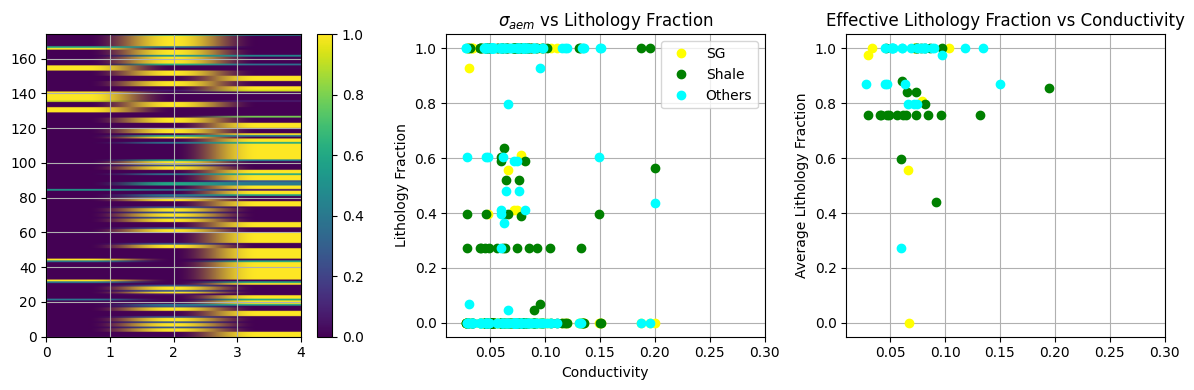

In [55]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(A_above_all, aspect="auto", cmap="viridis", extent=[0, 4, 0, A_above_all.shape[0]])
plt.colorbar()
plt.grid()
plt.subplot(1, 3, 2)
plt.plot(
    (b_above_all),
    A_above_all[:, 0],
    "o",
    label="SG",
    color=allocate_color("sg"),
)
plt.plot(
    (b_above_all),
    A_above_all[:, 1],
    "o",
    label="Shale",
    color=allocate_color("shale"),
)
plt.plot(
    (b_above_all),
    A_above_all[:, 2],
    "o",
    label="Others",
    color=allocate_color("others"),
)
# plt.xscale('log')
plt.xlim(1e-2, 3e-1)
plt.ylabel("Lithology Fraction")
plt.xlabel("Conductivity")
plt.title(r"$\sigma_{aem}$ vs Lithology Fraction")
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
# plt.xscale('log')
plt.xlim(1e-2, 3e-1)
plt.plot(b_above_avg[:, 0], A_above_avg[:, 0], "o", color=allocate_color("sg"), label="SG")
plt.plot(b_above_avg[:, 1], A_above_avg[:, 1], "o", color=allocate_color("shale"), label="Shale")
plt.plot(b_above_avg[:, 2], A_above_avg[:, 2], "o", color=allocate_color("others"), label="Others")
plt.ylabel("Average Lithology Fraction")
plt.title("Effective Lithology Fraction vs Conductivity")
plt.grid()
plt.tight_layout()
plt.show()

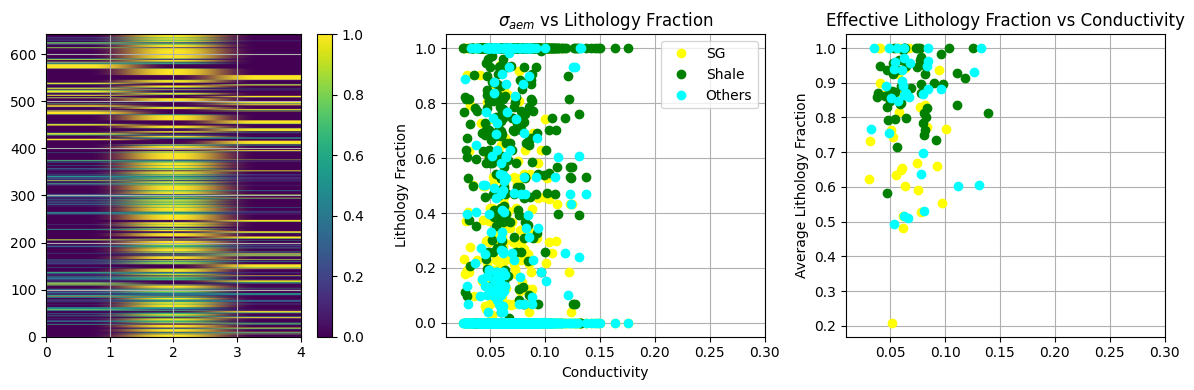

In [56]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(A_below_all, aspect="auto", cmap="viridis", extent=[0, 4, 0, A_below_all.shape[0]])
plt.colorbar()
plt.grid()
plt.subplot(1, 3, 2)
plt.plot(
    (b_below_all),
    A_below_all[:, 0],
    "o",
    label="SG",
    color=allocate_color("sg"),
)
plt.plot(
    (b_below_all),
    A_below_all[:, 1],
    "o",
    label="Shale",
    color=allocate_color("shale"),
)
plt.plot(
    (b_below_all),
    A_below_all[:, 2],
    "o",
    label="Others",
    color=allocate_color("others"),
)
# plt.xscale('log')
plt.xlim(1e-2, 3e-1)
plt.ylabel("Lithology Fraction")
plt.xlabel("Conductivity")
plt.title(r"$\sigma_{aem}$ vs Lithology Fraction")
plt.legend()
plt.grid()

plt.subplot(1, 3, 3)
# plt.xscale('log')
plt.xlim(1e-2, 3e-1)
plt.plot(b_below_avg[:, 0], A_below_avg[:, 0], "o", color=allocate_color("sg"), label="SG")
plt.plot(b_below_avg[:, 1], A_below_avg[:, 1], "o", color=allocate_color("shale"), label="Shale")
plt.plot(b_below_avg[:, 2], A_below_avg[:, 2], "o", color=allocate_color("others"), label="Others")
plt.ylabel("Average Lithology Fraction")
plt.title("Effective Lithology Fraction vs Conductivity")
plt.grid()
plt.tight_layout()
plt.show()

In [57]:
above_solution = calculate_linear_equation(A_above_all, b_above_all)
below_solution = calculate_linear_equation(A_below_all, b_below_all)

In [58]:
def run_bootstrap_inversion_by_well(A_by_well, b_by_well, iterations=1000, rng=None):
    """Bootstrap wells while retaining all AEM-layer equations from each sampled well."""
    well_equations = [
        (np.asarray(A, dtype=float), np.asarray(b, dtype=float).reshape(-1))
        for A, b in zip(A_by_well, b_by_well)
        if len(A) > 0 and len(b) > 0
    ]
    if not well_equations:
        raise ValueError("At least one well with equations is required.")

    n_wells = len(well_equations)
    n_lithologies = well_equations[0][0].shape[1]
    rng = np.random.default_rng() if rng is None else rng
    bootstrap_resistivities = np.full((iterations, n_lithologies), np.nan)

    for iteration in range(iterations):
        sampled_wells = rng.integers(0, n_wells, size=n_wells)
        A_resampled = np.vstack([well_equations[index][0] for index in sampled_wells])
        b_resampled = np.concatenate([well_equations[index][1] for index in sampled_wells])

        if np.linalg.matrix_rank(A_resampled) < n_lithologies:
            continue

        conductivity, _, _, _ = np.linalg.lstsq(A_resampled, b_resampled, rcond=None)
        if np.all(conductivity > 0):
            bootstrap_resistivities[iteration] = 1.0 / conductivity

    return bootstrap_resistivities

In [59]:
rng = np.random.default_rng(42)
bootstrap_res_above = run_bootstrap_inversion_by_well(
    A_above_joint,
    b_above_joint,
    iterations=1000,
    rng=rng,
)
bootstrap_res_below = run_bootstrap_inversion_by_well(
    A_below_joint,
    b_below_joint,
    iterations=1000,
    rng=rng,
)

for label, values in {
    "Above DTW": bootstrap_res_above,
    "Below DTW": bootstrap_res_below,
}.items():
    valid_values = values[np.isfinite(values).all(axis=1)]
    print(f"{label}: {len(valid_values)} valid bootstrap solutions")

Above DTW: 1000 valid bootstrap solutions

Below DTW: 1000 valid bootstrap solutions

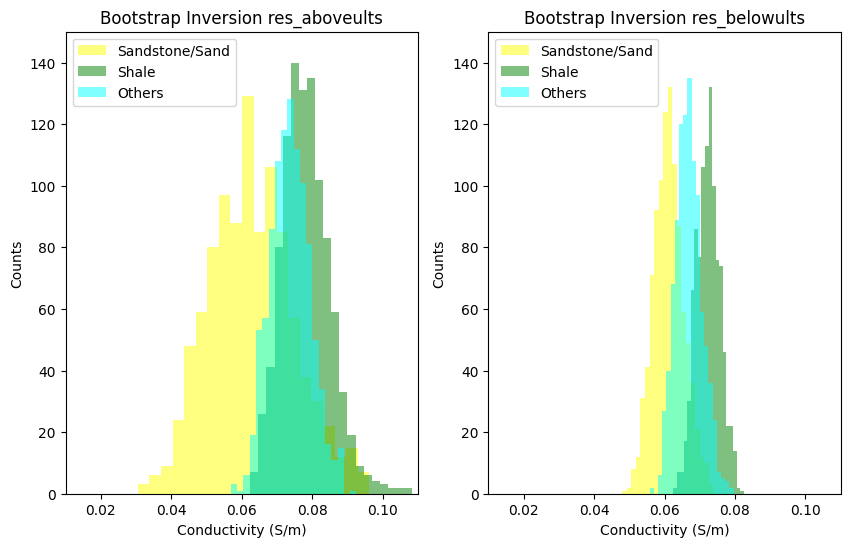

In [60]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.hist(
    1 / bootstrap_res_above[:, 0],
    bins=20,
    alpha=0.5,
    label="Sandstone/Sand",
    color=allocate_color("sg"),
)
plt.hist(
    1 / bootstrap_res_above[:, 1],
    bins=20,
    alpha=0.5,
    label="Shale",
    color=allocate_color("shale"),
)
plt.hist(
    1 / bootstrap_res_above[:, 2],
    bins=20,
    alpha=0.5,
    label="Others",
    color=allocate_color("others"),
)
plt.xlim(1e-2, 1.1e-1)
plt.ylim(0, 150)
plt.xlabel("Conductivity (S/m)")
plt.ylabel("Counts")
plt.title("Bootstrap Inversion res_aboveults")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(
    1 / bootstrap_res_below[:, 0],
    bins=20,
    alpha=0.5,
    label="Sandstone/Sand",
    color=allocate_color("sg"),
)
plt.hist(
    1 / bootstrap_res_below[:, 1],
    bins=20,
    alpha=0.5,
    label="Shale",
    color=allocate_color("shale"),
)
plt.hist(
    1 / bootstrap_res_below[:, 2],
    bins=20,
    alpha=0.5,
    label="Others",
    color=allocate_color("others"),
)
plt.xlim(1e-2, 1.1e-1)
plt.ylim(0, 150)
plt.xlabel("Conductivity (S/m)")
plt.ylabel("Counts")
plt.title("Bootstrap Inversion res_belowults")
plt.legend()

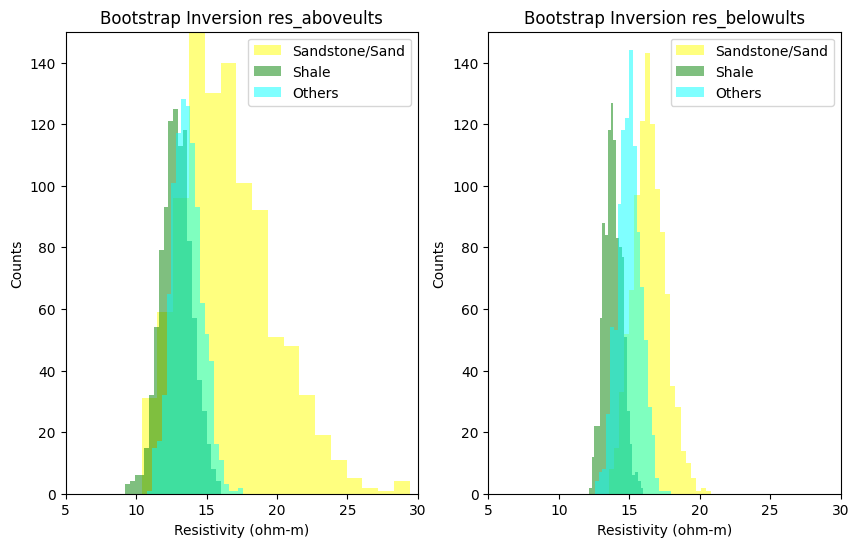

In [61]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.hist(
    bootstrap_res_above[:, 0],
    bins=20,
    alpha=0.5,
    label="Sandstone/Sand",
    color=allocate_color("sg"),
)
plt.hist(
    bootstrap_res_above[:, 1],
    bins=20,
    alpha=0.5,
    label="Shale",
    color=allocate_color("shale"),
)
plt.hist(
    bootstrap_res_above[:, 2],
    bins=20,
    alpha=0.5,
    label="Others",
    color=allocate_color("others"),
)
plt.xlim(5,30)
plt.ylim(0, 150)
plt.xlabel("Resistivity (ohm-m)")
plt.ylabel("Counts")
plt.title("Bootstrap Inversion res_aboveults")
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(
    bootstrap_res_below[:, 0],
    bins=20,
    alpha=0.5,
    label="Sandstone/Sand",
    color=allocate_color("sg"),
)
plt.hist(
    bootstrap_res_below[:, 1],
    bins=20,
    alpha=0.5,
    label="Shale",
    color=allocate_color("shale"),
)
plt.hist(
    bootstrap_res_below[:, 2],
    bins=20,
    alpha=0.5,
    label="Others",
    color=allocate_color("others"),
)
plt.xlim(5,30)
plt.ylim(0, 150)
plt.xlabel("Resistivity (ohm-m)")
plt.ylabel("Counts")
plt.title("Bootstrap Inversion res_belowults")
plt.legend()

In [62]:
# def calculate_aem_pixel_rho(depth:list, resistivity:list)->float:
#     if len(depth) != len(resistivity) + 1:
#         raise ValueError("Depth list mus have one more element including surface (z=0).")
#     depth = np.asarray(depth, dtype=float)
#     resistivity = np.asarray(resistivity, dtype=float)
#     thickness = np.diff(depth)
#     t_aem = np.sum(thickness)
#     rho_aem = np.sum(thickness/t_aem/resistivity)**(-1)
#     return rho_aem

# def sample_resistivitys_sets(well_index, n=75):
#     """Return the near ATEM locations and their resistivity profiles."""
#     target = well_df.iloc[well_index]
#     x = target["x"]
#     y = target["y"]
#     if target["well_type"] == "WaterWell":
#         mask = wl_df["name"] == float(target["well_id"])
#         log_top = wl_df.loc[mask, "top_m"].to_numpy(dtype=float)
#         log_bot = wl_df.loc[mask, "bottom_m"].to_numpy(dtype=float)
#         log_litho = wl_df.loc[mask, "litho"].to_numpy(dtype=str)
#     else:
#         mask = cl_df["name"] == target["well_name"]
#         log_top = cl_df.loc[mask, "top_m"].to_numpy(dtype=float)
#         log_bot = cl_df.loc[mask, "bottom_m"].to_numpy(dtype=float)
#         log_litho = cl_df.loc[mask, "litho"].to_numpy(dtype=str)

#     mask_clay = log_litho =="clay"
#     mask_sg = log_litho == "sg"
#     mask_mixed = log_litho == "mixed"
#     t_clay = np.sum(log_bot[mask_clay] - log_top[mask_clay])
#     t_sg = np.sum(log_bot[mask_sg] - log_top[mask_sg])
#     t_mixed = np.sum(log_bot[mask_mixed] - log_top[mask_mixed])
#     t_amem = depth_values[-1]

#     query_xy = np.asarray([[float(x), float(y)]], dtype=float)
#     distances, valid_index = model_tree.query(query_xy, k=n)
#     model_rows = valid_atem_df.iloc[valid_index[0]]
#     model_profiles = resis_values[xy_valid_maks][valid_index[0]].copy()
#     print(f"Sampled averaged distnace: {np.mean(distances):.2f} m, max distance: {np.max(distances):.2f} m")
#     return {
#         "x_wgs84": (model_rows["x_wgs84"]),
#         "y_wgs84": (model_rows["y_wgs84"]),
#         "distances": distances,
#         "resistivity": model_profiles,
#         "t_clay": t_clay,
#         "t_sg": t_sg,
#         "t_mixed": t_mixed,
#         "t_aem": t_amem
#     }


In [63]:
# def generate_matrix_A(t_sg:float, t_mixed:float, t_clay:float, t_aem:float, n_sample:int):
#     A = np.zeros((n_sample, 3), dtype=float)
#     A[:,0] = t_sg/t_aem
#     A[:,1] = t_mixed/t_aem
#     A[:,2] = t_clay/t_aem
#     return A


In [64]:
# output_dir = Path("../outputs/well_analysis")
# output_dir.mkdir(parents=True, exist_ok=True)

# lithology_rows = []
# logging_rows = []
# logging_missing_wells = []
# atem_rows = []

# for _, well in well_df.iterrows():
#     well_type = well["well_type"]
#     well_id = well["well_id"]
#     well_name = well["well_name"]

#     if well_type == "WaterWell":
#         lithology_mask = wl_df["name"] == float(well_id)
#         well_log_id = well_id
#         lithology_df = wl_df.loc[lithology_mask]
#     else:
#         lithology_mask = cl_df["name"] == well_name
#         well_log_id = well_name
#         lithology_df = cl_df.loc[lithology_mask]

#     for _, lithology in lithology_df.iterrows():
#         lithology_rows.append(
#             {
#                 "well_id": well_id,
#                 "well_name": well_name,
#                 "well_type": well_type,
#                 "well_log_id": well_log_id,
#                 "top_m": lithology["top_m"],
#                 "bottom_m": lithology["bottom_m"],
#                 "lithology": lithology["litho"],
#                 "colour": lithology["colour"],
#             }
#         )

#     depth, resis, gr, sp = load_well_las(well_name, well_type)
#     if depth is None or resis is None:
#         logging_missing_wells.append(
#             {
#                 "well_id": well_id,
#                 "well_name": well_name,
#                 "well_type": well_type,
#             }
#         )
#     else:
#         for depth_m, resistivity in zip(depth, resis):
#             logging_rows.append(
#                 {
#                     "well_id": well_id,
#                     "well_name": well_name,
#                     "well_type": well_type,
#                     "depth_m": depth_m,
#                     "logging_resistivity_ohm_m": resistivity,
#                 }
#             )

#     query_xy = np.asarray([[float(well["x"]), float(well["y"])]], dtype=float)
#     distance, valid_index = model_tree.query(query_xy, k=1)
#     distance = float(distance[0])
#     valid_index = int(valid_index[0])
#     atem_record = valid_atem_df.iloc[valid_index]
#     atem_profile = resis_values[xy_valid_maks][valid_index]

#     for depth_m, resistivity in zip(depth_values, atem_profile):
#         atem_rows.append(
#             {
#                 "well_id": well_id,
#                 "well_name": well_name,
#                 "well_type": well_type,
#                 "well_x": well["x"],
#                 "well_y": well["y"],
#                 "atem_x": atem_record["x_wgs84"],
#                 "atem_y": atem_record["y_wgs84"],
#                 "atem_distance_m": distance,
#                 "depth_m": depth_m,
#                 "atem_resistivity_ohm_m": resistivity,
#             }
#         )

# well_lithology_export_df = pd.DataFrame(lithology_rows)
# well_logging_export_df = pd.DataFrame(logging_rows)
# well_atem_export_df = pd.DataFrame(atem_rows)
# logging_missing_df = pd.DataFrame(logging_missing_wells)

# well_lithology_export_df.to_csv(output_dir / "well_lithology.csv", index=False)
# well_logging_export_df.to_csv(output_dir / "well_logging_resistivity.csv", index=False)
# well_atem_export_df.to_csv(output_dir / "well_atem_inversion.csv", index=False)

# print(f"Saved: {output_dir / 'well_lithology.csv'} ({len(well_lithology_export_df)} rows)")
# print(f"Saved: {output_dir / 'well_logging_resistivity.csv'} ({len(well_logging_export_df)} rows)")
# print(f"Saved: {output_dir / 'well_atem_inversion.csv'} ({len(well_atem_export_df)} rows)")
# print(f"Wells without logging resistivity: {len(logging_missing_df)}")

# loaded_lithology_df = pd.read_csv(output_dir / "well_lithology.csv")
# loaded_logging_df = pd.read_csv(output_dir / "well_logging_resistivity.csv")
# loaded_atem_df = pd.read_csv(output_dir / "well_atem_inversion.csv")

# assert {
#     "well_id",
#     "well_name",
#     "well_type",
#     "top_m",
#     "bottom_m",
#     "lithology",
# }.issubset(loaded_lithology_df.columns)
# assert {
#     "well_id",
#     "well_name",
#     "well_type",
#     "depth_m",
#     "logging_resistivity_ohm_m",
# }.issubset(loaded_logging_df.columns)
# assert {
#     "well_id",
#     "well_name",
#     "well_type",
#     "depth_m",
#     "atem_resistivity_ohm_m",
# }.issubset(loaded_atem_df.columns)

# print(f"Loaded lithology CSV: {loaded_lithology_df.shape}")
# print(f"Loaded logging CSV: {loaded_logging_df.shape}")
# print(f"Loaded ATEM CSV: {loaded_atem_df.shape}")

# plot_well_index = None
# for candidate_index, well in well_df.iterrows():
#     if well["well_type"] == "WaterWell":
#         colour_values = wl_df.loc[
#             wl_df["name"] == float(well["well_id"]),
#             "colour",
#         ]
#     else:
#         colour_values = cl_df.loc[
#             cl_df["name"] == well["well_name"],
#             "colour",
#         ]

#     if len(colour_values) > 0 and colour_values.notna().all():
#         plot_well_index = candidate_index
#         break

# if plot_well_index is None:
#     raise ValueError("No well with valid lithology colours was found for plotting.")

# print(f"Plot validation well index: {plot_well_index}")
# plot_resistivity_map(depth_index=0, well_index=plot_well_index)